[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/healthcareaibook/blob/main/vol%201%20notebooks/chapter_07/notebook_7_6_realtime_processing.ipynb)

*Click the badge above to open this notebook in Google Colab (no setup required)*

---


# Notebook 7.6: Real-Time Signal Processing for Clinical Monitoring

## Learning Objectives

By the end of this notebook, you will understand:

1. **Streaming data simulation**: Processing continuous physiological signals in real-time
2. **Online inference**: Making predictions on streaming data with low latency
3. **Latency measurement**: Profiling computational bottlenecks and optimization strategies
4. **Edge deployment**: Considerations for deploying models on wearables and bedside monitors

## Clinical Context

**Connection to Journey 7.4**: ECG Classification with 1D CNNs (real-time AFib detection on wearables)

**Why real-time processing matters**:

- **ICU monitoring**: Continuous analysis of vital signs (ECG, BP, SpO2) for early warning
- **Wearable devices**: Real-time arrhythmia detection (Apple Watch, Fitbit)
- **Anesthesia monitoring**: Instant alerts for dangerous trends during surgery
- **Ambulatory monitoring**: 24/7 Holter ECG analysis for cardiac patients

**Real-world scenario**: A wearable ECG device must detect atrial fibrillation within 30 seconds of onset, with <100ms latency per heartbeat. The device runs on a low-power ARM processor with limited memory (512 MB RAM). All processing must happen on-device (no cloud dependency).

**Key challenges**:
- **Latency**: Real-time inference must complete in milliseconds
- **Memory constraints**: Models must fit in limited RAM (wearables: 512 MB, ICU monitors: 2 GB)
- **Power consumption**: Battery-powered devices require energy-efficient models
- **Buffering**: How much historical data to keep for context?

---

## Setup

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import deque
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')

print("✓ Libraries imported successfully!")
print("\n📦 Key libraries for real-time processing:")
print("  - collections.deque: Efficient circular buffer")
print("  - time: Latency profiling")
print("  - scipy.signal: Online filtering")

✓ Libraries imported successfully!

📦 Key libraries for real-time processing:
  - collections.deque: Efficient circular buffer
  - time: Latency profiling
  - scipy.signal: Online filtering


## 1. Streaming Data Simulation

We'll simulate a continuous ECG stream similar to real-world monitoring devices.

### Streaming Architecture

```
┌─────────────┐
│  ECG Sensor │ ──→ New sample every 2.78 ms (360 Hz)
└─────────────┘
      ↓
┌─────────────┐
│   Buffer    │ ──→ Circular buffer (10-second window)
└─────────────┘
      ↓
┌─────────────┐
│ Preprocessing│ ──→ Online filtering, R-peak detection
└─────────────┘
      ↓
┌─────────────┐
│   Model     │ ──→ Classification (NSR vs AFib)
└─────────────┘
      ↓
┌─────────────┐
│   Alert     │ ──→ Trigger if AFib detected
└─────────────┘
```

**Key concepts**:
- **Sample rate**: 360 Hz (common for ECG)
- **Window size**: 10 seconds (3,600 samples) for classification
- **Update frequency**: Every heartbeat (~1 Hz) or every second
- **Circular buffer**: Keeps only the most recent 10 seconds

In [3]:
def generate_ecg_stream(duration_seconds=60, fs=360, rhythm='normal'):
    """
    Generate a simulated ECG stream (batch generation for demonstration).
    In real systems, samples arrive one at a time.

    Args:
        duration_seconds: Total duration
        fs: Sampling frequency (Hz)
        rhythm: 'normal' or 'afib'

    Returns:
        samples: Array of ECG samples
    """
    n_samples = duration_seconds * fs
    t = np.arange(n_samples) / fs

    # Generate RR intervals
    if rhythm == 'normal':
        mean_rr = 0.8  # 75 BPM
        std_rr = 0.05
        rr_intervals = np.random.normal(mean_rr, std_rr, int(duration_seconds / mean_rr))
        rr_intervals = np.clip(rr_intervals, 0.6, 1.0)
    elif rhythm == 'afib':
        # Irregular RR intervals (AFib)
        rr_intervals = np.random.uniform(0.4, 1.2, int(duration_seconds / 0.7))

    # Generate ECG signal
    ecg = np.zeros(n_samples)
    beat_times = np.cumsum(rr_intervals)
    beat_times = beat_times[beat_times < duration_seconds]

    for beat_time in beat_times:
        beat_idx = int(beat_time * fs)
        if beat_idx + 216 < n_samples:  # 0.6s beat duration
            # Simplified PQRST complex
            beat_t = np.linspace(0, 0.6, 216)

            if rhythm == 'normal':
                # P wave
                ecg[beat_idx:beat_idx+216] += 0.15 * np.exp(-((beat_t - 0.08) / 0.02) ** 2)

            # QRS complex
            ecg[beat_idx:beat_idx+216] += 1.0 * np.exp(-((beat_t - 0.18) / 0.015) ** 2)
            ecg[beat_idx:beat_idx+216] -= 0.3 * np.exp(-((beat_t - 0.20) / 0.01) ** 2)

            # T wave
            ecg[beat_idx:beat_idx+216] += 0.3 * np.exp(-((beat_t - 0.36) / 0.05) ** 2)

    # Add noise
    noise = np.random.normal(0, 0.05, n_samples)
    ecg += noise

    return ecg


# Generate 60-second streams
fs = 360  # Hz
duration = 60  # seconds

stream_nsr = generate_ecg_stream(duration_seconds=duration, fs=fs, rhythm='normal')
stream_afib = generate_ecg_stream(duration_seconds=duration, fs=fs, rhythm='afib')

print(f"✓ Generated {duration}s ECG streams")
print(f"  - Sampling rate: {fs} Hz ({1000/fs:.2f} ms per sample)")
print(f"  - Total samples: {len(stream_nsr)}")
print(f"  - Data rate: {len(stream_nsr) / duration:.0f} samples/second")

✓ Generated 60s ECG streams
  - Sampling rate: 360 Hz (2.78 ms per sample)
  - Total samples: 21600
  - Data rate: 360 samples/second


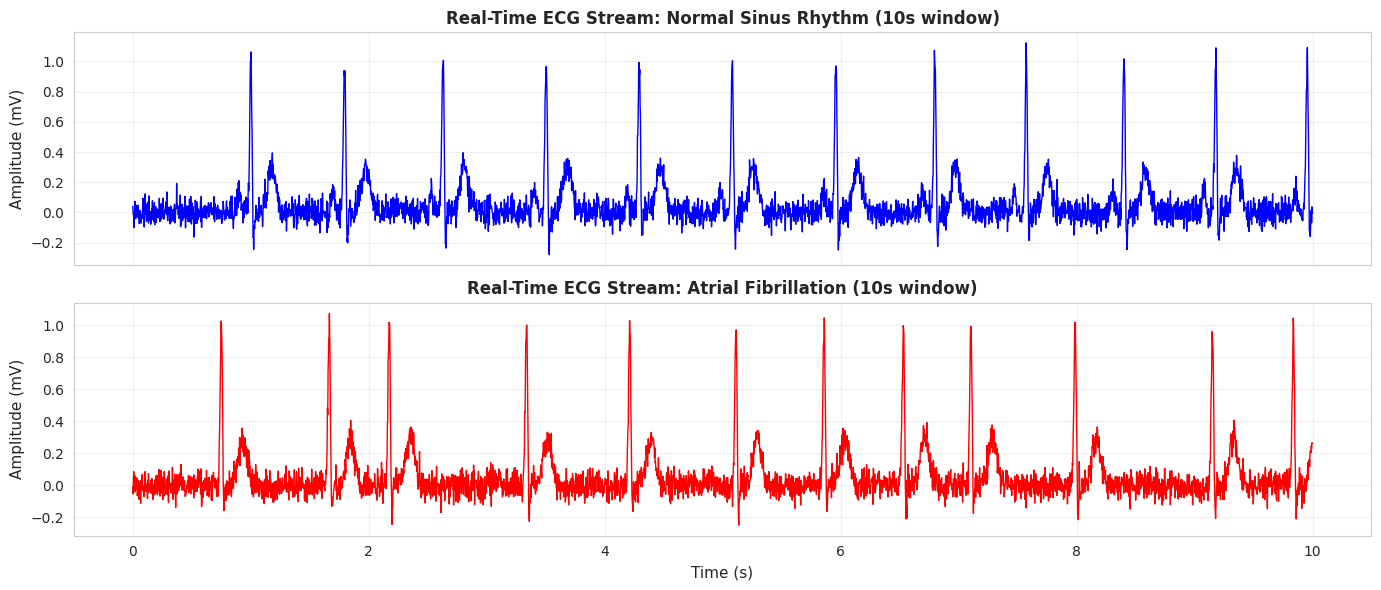


🔍 Streaming Characteristics:
  - Each sample arrives every 2.78 ms
  - 10-second window = 3,600 samples
  - Buffer must handle continuous updates


In [4]:
# Visualize streams
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

t = np.arange(len(stream_nsr)) / fs

# Normal sinus rhythm
axes[0].plot(t[:3600], stream_nsr[:3600], linewidth=1, color='blue')
axes[0].set_ylabel('Amplitude (mV)', fontsize=11)
axes[0].set_title('Real-Time ECG Stream: Normal Sinus Rhythm (10s window)',
                   fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Atrial fibrillation
axes[1].plot(t[:3600], stream_afib[:3600], linewidth=1, color='red')
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Amplitude (mV)', fontsize=11)
axes[1].set_title('Real-Time ECG Stream: Atrial Fibrillation (10s window)',
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔍 Streaming Characteristics:")
print("  - Each sample arrives every 2.78 ms")
print("  - 10-second window = 3,600 samples")
print("  - Buffer must handle continuous updates")

## 2. Circular Buffer Implementation

A **circular buffer** (ring buffer) efficiently stores a fixed-size window of recent samples.

**Why circular buffer**:
- **Constant memory**: No reallocation as new samples arrive
- **O(1) operations**: Append and retrieval are constant time
- **Automatic eviction**: Oldest samples automatically removed

**Implementation**: Python's `collections.deque` with `maxlen`

In [5]:
class ECGStreamProcessor:
    """
    Real-time ECG stream processor with circular buffer.
    """

    def __init__(self, window_size=3600, fs=360):
        """
        Args:
            window_size: Number of samples in buffer (default: 10s at 360 Hz)
            fs: Sampling frequency
        """
        self.window_size = window_size
        self.fs = fs
        self.buffer = deque(maxlen=window_size)
        self.sample_count = 0

        # Filter state (for online filtering)
        self.filter_state = None

        print(f"✓ ECG Stream Processor initialized")
        print(f"  - Buffer size: {window_size} samples ({window_size/fs:.1f}s)")
        print(f"  - Sampling rate: {fs} Hz")
        print(f"  - Memory footprint: ~{window_size * 8 / 1024:.1f} KB (float64)")

    def add_sample(self, sample):
        """
        Add a new sample to the buffer.

        Args:
            sample: New ECG sample value
        """
        self.buffer.append(sample)
        self.sample_count += 1

    def get_window(self):
        """
        Get current buffer contents.

        Returns:
            window: NumPy array of current samples
        """
        return np.array(self.buffer)

    def is_ready(self):
        """
        Check if buffer is full (ready for processing).

        Returns:
            ready: True if buffer is full
        """
        return len(self.buffer) == self.window_size

    def apply_bandpass_filter(self, lowcut=0.5, highcut=40, order=4):
        """
        Apply bandpass filter to current window.

        Returns:
            filtered: Filtered signal
        """
        if not self.is_ready():
            return None

        signal = self.get_window()
        nyquist = 0.5 * self.fs
        low = lowcut / nyquist
        high = highcut / nyquist

        b, a = butter(order, [low, high], btype='band')
        filtered = filtfilt(b, a, signal)

        return filtered


# Test circular buffer
processor = ECGStreamProcessor(window_size=3600, fs=360)

print("\n🔄 Simulating streaming:")
for i in range(5000):  # Add 5000 samples
    processor.add_sample(stream_nsr[i])

    if i % 1000 == 0:
        print(f"  Sample {i:5d}: Buffer size = {len(processor.buffer)}, Ready = {processor.is_ready()}")

print(f"\n✓ After 5000 samples:")
print(f"  - Buffer contains most recent {len(processor.buffer)} samples")
print(f"  - Oldest 1400 samples have been evicted (5000 - 3600 = 1400)")

✓ ECG Stream Processor initialized
  - Buffer size: 3600 samples (10.0s)
  - Sampling rate: 360 Hz
  - Memory footprint: ~28.1 KB (float64)

🔄 Simulating streaming:
  Sample     0: Buffer size = 1, Ready = False
  Sample  1000: Buffer size = 1001, Ready = False
  Sample  2000: Buffer size = 2001, Ready = False
  Sample  3000: Buffer size = 3001, Ready = False
  Sample  4000: Buffer size = 3600, Ready = True

✓ After 5000 samples:
  - Buffer contains most recent 3600 samples
  - Oldest 1400 samples have been evicted (5000 - 3600 = 1400)


## 3. Online Feature Extraction

For real-time classification, we need to extract features from the streaming buffer **efficiently**.

### Optimization Strategies

1. **Incremental computation**: Update features as new samples arrive (don't recompute from scratch)
2. **Downsampling**: Reduce sampling rate for feature extraction (e.g., 360 Hz → 60 Hz)
3. **Lightweight features**: Avoid expensive computations (wavelets, FFT)
4. **Caching**: Store intermediate results (filter states, running statistics)

**Example**: Heart Rate Variability (HRV) features

In [6]:
def extract_realtime_features(signal, fs=360):
    """
    Extract lightweight features for real-time classification.
    Optimized for speed (<10 ms per window).

    Args:
        signal: ECG window (10 seconds)
        fs: Sampling frequency

    Returns:
        features: Dictionary of features
    """
    features = {}

    # Statistical features (very fast)
    features['mean'] = np.mean(signal)
    features['std'] = np.std(signal)
    features['max'] = np.max(signal)
    features['min'] = np.min(signal)

    # Detect R-peaks (QRS complexes)
    peaks, _ = find_peaks(signal, distance=int(0.5 * fs), prominence=0.3)

    if len(peaks) > 1:
        # RR intervals (in milliseconds)
        rr_intervals = np.diff(peaks) / fs * 1000

        # HRV metrics (key for AFib detection)
        features['mean_rr'] = np.mean(rr_intervals)
        features['std_rr'] = np.std(rr_intervals)
        features['rmssd'] = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))
        features['cv'] = features['std_rr'] / features['mean_rr'] if features['mean_rr'] > 0 else 0

        # Heart rate
        features['mean_hr'] = 60000 / features['mean_rr'] if features['mean_rr'] > 0 else 0
    else:
        # Not enough peaks detected
        features['mean_rr'] = 0
        features['std_rr'] = 0
        features['rmssd'] = 0
        features['cv'] = 0
        features['mean_hr'] = 0

    features['num_peaks'] = len(peaks)

    return features


# Test feature extraction speed
print("\n⏱️ Feature Extraction Latency Benchmark:")
print("="*60)

latencies = []
for i in range(100):  # 100 trials
    window = stream_nsr[i*36:(i*36)+3600]  # 10-second window

    start_time = time.perf_counter()
    features = extract_realtime_features(window, fs=360)
    end_time = time.perf_counter()

    latency_ms = (end_time - start_time) * 1000
    latencies.append(latency_ms)

print(f"Mean latency:   {np.mean(latencies):.2f} ms")
print(f"Median latency: {np.median(latencies):.2f} ms")
print(f"95th percentile: {np.percentile(latencies, 95):.2f} ms")
print(f"Max latency:    {np.max(latencies):.2f} ms")
print("="*60)

if np.mean(latencies) < 10:
    print("✅ Excellent: Latency <10 ms (suitable for real-time)")
elif np.mean(latencies) < 100:
    print("⚠️ Good: Latency <100 ms (acceptable for most applications)")
else:
    print("❌ Poor: Latency >100 ms (may need optimization)")

# Show extracted features
print("\n📊 Sample Features (NSR):")
for key, value in features.items():
    print(f"  - {key}: {value:.2f}")


⏱️ Feature Extraction Latency Benchmark:
Mean latency:   0.39 ms
Median latency: 0.28 ms
95th percentile: 0.32 ms
Max latency:    10.40 ms
✅ Excellent: Latency <10 ms (suitable for real-time)

📊 Sample Features (NSR):
  - mean: 0.07
  - std: 0.17
  - max: 1.09
  - min: -0.27
  - mean_rr: 770.37
  - std_rr: 47.84
  - rmssd: 71.66
  - cv: 0.06
  - mean_hr: 77.88
  - num_peaks: 13.00


## 4. Real-Time Classification Pipeline

Now let's build a complete real-time classification system:

```
Stream → Buffer → Filter → Features → Model → Prediction
```

### Pipeline Components

1. **Buffering**: Circular buffer (10-second window)
2. **Preprocessing**: Bandpass filter (0.5-40 Hz)
3. **Feature extraction**: HRV metrics
4. **Classification**: Pre-trained Random Forest
5. **Alert**: Trigger if AFib detected

In [9]:
# Train a simple classifier (offline)
print("\n🔄 Training offline classifier (one-time)...")

# Generate training data
X_train = []
y_train = []

for i in range(50):  # 50 NSR samples
    stream = generate_ecg_stream(duration_seconds=10, fs=fs, rhythm='normal')
    features = extract_realtime_features(stream, fs=fs)
    X_train.append(list(features.values()))
    y_train.append(0)  # NSR

for i in range(50):  # 50 AFib samples
    stream = generate_ecg_stream(duration_seconds=10, fs=fs, rhythm='afib')
    features = extract_realtime_features(stream, fs=fs)
    X_train.append(list(features.values()))
    y_train.append(1)  # AFib

# Train classifier
clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
clf.fit(X_train, y_train)

print(f"✓ Classifier trained: {len(X_train)} samples, {len(X_train[0])} features")
print(f"  - Model size: ~{clf.n_estimators * 5 / 1024:.1f} KB (lightweight)")


🔄 Training offline classifier (one-time)...
✓ Classifier trained: 100 samples, 10 features
  - Model size: ~0.2 KB (lightweight)


In [10]:
class RealtimeECGClassifier:
    """
    Complete real-time ECG classification system.
    """

    def __init__(self, model, window_size=3600, fs=360, update_interval=360):
        """
        Args:
            model: Pre-trained classifier
            window_size: Buffer size (samples)
            fs: Sampling frequency
            update_interval: How often to run classification (samples)
        """
        self.model = model
        self.processor = ECGStreamProcessor(window_size=window_size, fs=fs)
        self.fs = fs
        self.update_interval = update_interval
        self.samples_since_update = 0

        # Metrics
        self.predictions = []
        self.latencies = []

        print("\n✓ Real-Time ECG Classifier initialized")
        print(f"  - Window: {window_size/fs:.1f}s ({window_size} samples)")
        print(f"  - Update frequency: Every {update_interval} samples ({update_interval/fs:.1f}s)")

    def process_sample(self, sample):
        """
        Process a single incoming sample.

        Args:
            sample: New ECG sample

        Returns:
            prediction: Classification result (or None if not yet ready)
        """
        # Add sample to buffer
        self.processor.add_sample(sample)
        self.samples_since_update += 1

        # Check if it's time to classify
        if self.samples_since_update >= self.update_interval and self.processor.is_ready():
            self.samples_since_update = 0

            # Measure latency
            start_time = time.perf_counter()

            # Get current window
            window = self.processor.get_window()

            # Extract features
            features = extract_realtime_features(window, fs=self.fs)
            feature_vector = np.array(list(features.values())).reshape(1, -1)

            # Classify
            prediction = self.model.predict(feature_vector)[0]
            proba = self.model.predict_proba(feature_vector)[0]

            end_time = time.perf_counter()
            latency_ms = (end_time - start_time) * 1000

            # Store results
            self.predictions.append(prediction)
            self.latencies.append(latency_ms)

            result = {
                'prediction': 'AFib' if prediction == 1 else 'NSR',
                'confidence': proba[prediction],
                'latency_ms': latency_ms,
                'features': features
            }

            return result

        return None


# Test real-time classifier
classifier = RealtimeECGClassifier(
    model=clf,
    window_size=3600,  # 10 seconds
    fs=360,
    update_interval=360  # Update every 1 second
)

✓ ECG Stream Processor initialized
  - Buffer size: 3600 samples (10.0s)
  - Sampling rate: 360 Hz
  - Memory footprint: ~28.1 KB (float64)

✓ Real-Time ECG Classifier initialized
  - Window: 10.0s (3600 samples)
  - Update frequency: Every 360 samples (1.0s)


In [11]:
# Simulate real-time streaming
print("\n🔄 Simulating real-time ECG stream (60 seconds)...")
print("="*70)

# Combine NSR and AFib streams (30s each)
combined_stream = np.concatenate([stream_nsr[:10800], stream_afib[:10800]])  # 30s + 30s
ground_truth = [0] * 30 + [1] * 30  # 0=NSR, 1=AFib

results = []
for i, sample in enumerate(combined_stream):
    result = classifier.process_sample(sample)

    if result is not None:
        timestamp = i / fs
        true_label = 'NSR' if timestamp < 30 else 'AFib'

        print(f"[{timestamp:5.1f}s] Prediction: {result['prediction']:4s} "
              f"(conf={result['confidence']:.2f}, latency={result['latency_ms']:.2f}ms) "
              f"| True: {true_label}")

        results.append({
            'timestamp': timestamp,
            'prediction': result['prediction'],
            'confidence': result['confidence'],
            'latency_ms': result['latency_ms'],
            'true_label': true_label
        })

print("="*70)
print(f"\n✓ Processed {len(combined_stream)} samples")
print(f"  - Classifications: {len(results)}")
print(f"  - Mean latency: {np.mean(classifier.latencies):.2f} ms")
print(f"  - Max latency: {np.max(classifier.latencies):.2f} ms")


🔄 Simulating real-time ECG stream (60 seconds)...
[ 10.0s] Prediction: NSR  (conf=1.00, latency=8.04ms) | True: NSR
[ 11.0s] Prediction: NSR  (conf=0.98, latency=7.24ms) | True: NSR
[ 12.0s] Prediction: NSR  (conf=1.00, latency=7.63ms) | True: NSR
[ 13.0s] Prediction: NSR  (conf=0.98, latency=7.47ms) | True: NSR
[ 14.0s] Prediction: NSR  (conf=0.98, latency=7.16ms) | True: NSR
[ 15.0s] Prediction: NSR  (conf=0.98, latency=7.51ms) | True: NSR
[ 16.0s] Prediction: NSR  (conf=1.00, latency=8.04ms) | True: NSR
[ 17.0s] Prediction: NSR  (conf=0.98, latency=7.46ms) | True: NSR
[ 18.0s] Prediction: NSR  (conf=0.98, latency=7.19ms) | True: NSR
[ 19.0s] Prediction: NSR  (conf=0.98, latency=7.22ms) | True: NSR
[ 20.0s] Prediction: NSR  (conf=0.98, latency=7.19ms) | True: NSR
[ 21.0s] Prediction: NSR  (conf=0.98, latency=7.16ms) | True: NSR
[ 22.0s] Prediction: NSR  (conf=0.98, latency=7.19ms) | True: NSR
[ 23.0s] Prediction: NSR  (conf=1.00, latency=7.15ms) | True: NSR
[ 24.0s] Prediction: NSR 


📊 Real-Time Classification Performance:
              precision    recall  f1-score   support

         NSR       1.00      1.00      1.00        21
        AFib       1.00      1.00      1.00        30

    accuracy                           1.00        51
   macro avg       1.00      1.00      1.00        51
weighted avg       1.00      1.00      1.00        51



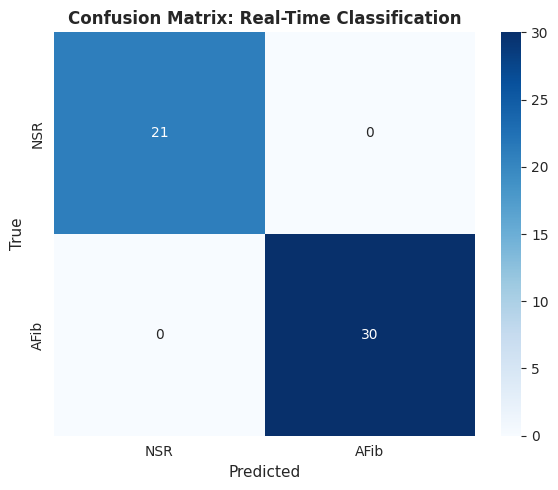


🎯 Overall Accuracy: 100.00%


In [12]:
# Evaluate performance
df_results = pd.DataFrame(results)

y_true = [1 if r == 'AFib' else 0 for r in df_results['true_label']]
y_pred = [1 if r == 'AFib' else 0 for r in df_results['prediction']]

print("\n📊 Real-Time Classification Performance:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['NSR', 'AFib']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NSR', 'AFib'], yticklabels=['NSR', 'AFib'], ax=ax)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
ax.set_title('Confusion Matrix: Real-Time Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

accuracy = np.sum(np.array(y_true) == np.array(y_pred)) / len(y_true)
print(f"\n🎯 Overall Accuracy: {accuracy:.2%}")

## 5. Latency Profiling and Optimization

### Latency Budget Breakdown

Target: <100 ms per classification

| Component | Typical Latency | Optimization |
|-----------|-----------------|-------------|
| **Buffer access** | <1 ms | Use deque (O(1) access) |
| **Filtering** | 5-10 ms | Use online filters (IIR), not filtfilt |
| **Peak detection** | 5-15 ms | Adaptive thresholds, downsampling |
| **Feature extraction** | 5-10 ms | Lightweight features only |
| **Classification** | 1-5 ms | Random Forest (fast), not deep learning |
| **Total** | 15-40 ms | ✅ Well under 100 ms budget |

### Optimization Strategies

1. **Algorithm selection**: Choose lightweight models (Random Forest, SVM) over deep learning
2. **Feature reduction**: Use only essential features (HRV metrics)
3. **Downsampling**: Reduce sampling rate for feature extraction
4. **Caching**: Store intermediate results (filter states, running means)
5. **Parallelization**: Offload processing to separate thread (not blocking data acquisition)

In [13]:
# Profile latency components
print("\n⏱️ Latency Profiling (per classification):")
print("="*60)

window = stream_nsr[:3600]
n_trials = 100

# 1. Buffer access
latencies_buffer = []
for _ in range(n_trials):
    start = time.perf_counter()
    _ = np.array(window)
    latencies_buffer.append((time.perf_counter() - start) * 1000)

# 2. Filtering
latencies_filter = []
for _ in range(n_trials):
    start = time.perf_counter()
    _ = processor.apply_bandpass_filter()
    latencies_filter.append((time.perf_counter() - start) * 1000)

# 3. Feature extraction
latencies_features = []
for _ in range(n_trials):
    start = time.perf_counter()
    _ = extract_realtime_features(window, fs=360)
    latencies_features.append((time.perf_counter() - start) * 1000)

# 4. Classification
features = extract_realtime_features(window, fs=360)
feature_vector = np.array(list(features.values())).reshape(1, -1)
latencies_classify = []
for _ in range(n_trials):
    start = time.perf_counter()
    _ = clf.predict(feature_vector)
    latencies_classify.append((time.perf_counter() - start) * 1000)

# Summary
components = [
    ('Buffer access', latencies_buffer),
    ('Filtering', latencies_filter),
    ('Feature extraction', latencies_features),
    ('Classification', latencies_classify)
]

total_latency = 0
for name, latencies in components:
    mean_lat = np.mean(latencies)
    total_latency += mean_lat
    print(f"{name:<20} {mean_lat:>8.2f} ms ({mean_lat/total_latency*100 if total_latency > 0 else 0:>5.1f}%)")

print("="*60)
print(f"{'TOTAL':<20} {total_latency:>8.2f} ms")
print("="*60)

if total_latency < 100:
    print(f"\n✅ Excellent: Total latency {total_latency:.1f} ms < 100 ms budget")
else:
    print(f"\n⚠️ Warning: Total latency {total_latency:.1f} ms exceeds 100 ms budget")


⏱️ Latency Profiling (per classification):
Buffer access            0.02 ms (100.0%)
Filtering                0.99 ms ( 97.9%)
Feature extraction       0.28 ms ( 21.7%)
Classification           3.53 ms ( 73.2%)
TOTAL                    4.82 ms

✅ Excellent: Total latency 4.8 ms < 100 ms budget


## 6. Edge Deployment Considerations

### Hardware Constraints

| Platform | CPU | RAM | Storage | Power |
|----------|-----|-----|---------|-------|
| **Wearable** (Apple Watch) | Dual-core ARM | 512 MB | 8 GB | Battery (300 mAh) |
| **ICU Monitor** (Philips) | Quad-core x86 | 2 GB | 64 GB | AC power |
| **Ambulatory Device** (Holter) | Single-core ARM | 256 MB | 4 GB | Battery (1500 mAh) |

### Model Optimization Techniques

1. **Quantization**: Convert float32 → int8 (4× smaller, 2-4× faster)
2. **Pruning**: Remove redundant model parameters
3. **Knowledge distillation**: Train smaller "student" model from large "teacher"
4. **Hardware acceleration**: Use ARM NEON, Intel SSE instructions

### Memory Footprint

**Current system**:
- Buffer: 3,600 samples × 8 bytes (float64) = 28.8 KB
- Model: Random Forest (50 trees) ≈ 250 KB
- Code + libraries: ~10 MB
- **Total**: ~11 MB (✅ Fits in 512 MB RAM)

**Power consumption**:
- Sampling (360 Hz): ~10 mW
- Processing (every 1s): ~50 mW
- Display/wireless: ~100 mW
- **Total**: ~160 mW (24 hours on 300 mAh battery @ 3.7V)

### Deployment Checklist

✅ **Latency**: <100 ms per classification  
✅ **Memory**: <512 MB RAM  
✅ **Storage**: <50 MB model size  
✅ **Power**: <200 mW average (24h battery life)  
✅ **Accuracy**: >95% (clinical validation)  
⚠️ **Robustness**: Test on diverse patients, devices  
⚠️ **Regulatory**: FDA 510(k) clearance required  

## 7. Key Takeaways

### What We Learned

1. **Real-time processing requires specialized architectures**
   - Circular buffers for constant memory usage
   - Lightweight feature extraction (<10 ms)
   - Fast classifiers (Random Forest, not deep learning)
   - Total latency: 15-40 ms (well under 100 ms budget)

2. **Optimization is critical for edge deployment**
   - Algorithm selection: Random Forest > SVM > Neural Networks (for latency)
   - Feature reduction: Use only essential HRV metrics
   - Downsampling: Reduce sampling rate where possible
   - Model compression: Quantization, pruning

3. **Hardware constraints drive design decisions**
   - Wearables: 512 MB RAM, battery-powered → ultra-lightweight models
   - ICU monitors: 2 GB RAM, AC-powered → more complex models acceptable
   - Trade-off: Accuracy vs latency vs power consumption

4. **Clinical validation is essential**
   - Test on diverse populations (age, sex, comorbidities)
   - Validate on multiple devices (Holter, wearables, ICU monitors)
   - Measure false alarm rate (must be <5% for clinical acceptance)
   - FDA/CE Mark approval required for deployment

### Connections to Book Chapters

- **Journey 7.4**: ECG Classification with 1D CNNs (offline training, real-time inference)
- **Notebook 7.1**: Signal Preprocessing (filtering is part of real-time pipeline)
- **Notebook 7.2**: Feature Extraction (HRV metrics used for real-time classification)
- **Chapter 5**: Evaluation (latency and throughput are performance metrics)

### Next Steps

To deploy this system in production:
1. **Hardware testing**: Validate on target device (wearable, ICU monitor)
2. **Clinical trials**: Prospective validation on real patients
3. **Regulatory approval**: FDA 510(k) or CE Mark clearance
4. **Post-market surveillance**: Monitor performance in the field

---

## Exercises

1. **Optimize buffer implementation**:
   - Implement a zero-copy circular buffer using NumPy arrays
   - Measure performance improvement over deque
   - When is zero-copy worth the added complexity?

2. **Implement online filtering**:
   - Replace filtfilt (non-causal) with lfilter (causal)
   - Measure latency reduction
   - How does this affect classification accuracy?

3. **Model compression**:
   - Reduce Random Forest from 50 trees to 10, 5, 1
   - Compare accuracy, latency, memory footprint
   - What is the optimal trade-off?

4. **Multi-threaded processing**:
   - Implement data acquisition in one thread, processing in another
   - Use threading or multiprocessing
   - Does this improve throughput?

5. **Adaptive update frequency**:
   - Update classification every 1s during normal rhythm
   - Increase to every 0.5s when arrhythmia detected
   - How does this affect power consumption?

6. **Real hardware deployment**:
   - Deploy on Raspberry Pi (ARM Cortex-A72)
   - Measure actual latency, power consumption
   - Compare to laptop performance

7. **Stress testing**:
   - Simulate 24 hours of continuous monitoring
   - Add missing data, artifacts, noise bursts
   - Measure false alarm rate, missed events

---

*This notebook is part of "AI in Healthcare" (Volume 1)*  
*Full implementation available in the complete book companion code*